<a href="https://colab.research.google.com/github/abhishekanand04/Probability-and-Stats/blob/feature%2Fupdate/Nov24_PD_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import poisson, expon, geom

Example: Q. You receive 240 messages per hour on average - assume Poisson distributed.

Rate of messages arriving per second is 1/15.

In [ ]:
240/(60*60)

0.06666666666666667

In [ ]:
1/15

0.06666666666666667

Q1) What is the probability of having no message in 10 seconds?

In [ ]:
# lam = 10/15

poisson.pmf(k=0, mu=10/15)

0.513417119032592

In [ ]:
# Q2) P[T > 10], scale = 1/lambad = 1/(1/15) = 15
1- expon.cdf(x=10, scale=15)

0.513417119032592

In [ ]:
# Q3) P[T <= 10]
expon.cdf(x=10, scale=15)

0.486582880967408

You are working as a data engineer who has to resolve any bugs/
failures of machine learning models in production.
The time taken to debug is exponentially distributed with mean of 5 minutes

In [ ]:
# The time taken to debug is exponentially distributed with mean of 5 minutes.
# 1 bug can be solved on average in 5 min.              -> beta
# How many bugs can be solve in 1 min on average -> 1/5 -> lam

# lam = 1/5
# beta = 1 / lam = 5

Q1 Find the probability of debugging in 4 to 5 minutes

In [ ]:
# P[4 < T < 5] = P[T <= 5] - P[T <= 4]
prob = expon.cdf(x=5, scale=5) - expon.cdf(x=4, scale=5)
prob

0.08144952294577923

Q2 Find the probability of needing more than 6 minutes to debug

In [ ]:
# P[T > 6] = 1 - P[T <= 6]
prob = 1 - expon.cdf(x=6, scale=5)
prob

0.3011942119122022

Q3. Given that you have already spent 3 minutes, what is the probability of needing more than 9 minutes

In [ ]:
# P[T > 9 | T > 3] = ?

# P(A | B) = P(A intersection B) / P(B)

# P[T > 9 | T > 3] = P[T > 9 intersection T > 3] / P[T > 3]

# P[T > 9 intersection T > 3] = P[T > 9]

# P[T > 9 | T > 3] = P[T > 9] / P[T > 3]

# P[T > 9] = 1 - P[T <= 9]
a = (1 - expon.cdf(x=9, scale=5))

# P[T > 3] = 1 - P[T <= 3]
b = (1 - expon.cdf(x=3, scale=5))

p = a/b
p

0.30119421191220214

**Memoryless property of the Exponential distribution:**

The memoryless property essentially means that the time you've already spent on an event doesn't affect the future waiting time.


*   In the context of the exponential distribution, it means that the probability of needing more time in the future is the same, regardless of how much time has already passed.


For example, in the first question, we want to find the probability of needing more than 6 minutes to debug. Let's call this event A.

In the second question, we're interested in the probability of needing more than 9 minutes given that we've already spent 3 minutes, which we'll call event B.

The memoryless property tells us that the probability of event B, is the same as the probability of event A.
This is because the exponential distribution treats each moment as if you're starting new, regardless of the past.

In [ ]:
# ------

Suppose you have a system that fails, on average, every 50 hours.


What is the probability that the system will fail within the first 20 hours?

In [ ]:
# lam = 1/50
# scale = 50

# P[T <= 20]

expon.cdf(x = 20, scale = 50)

0.3296799539643607

<ipython-input-12-e21d657e691f>:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data, hist=False, kde=True)


<Axes: ylabel='Density'>

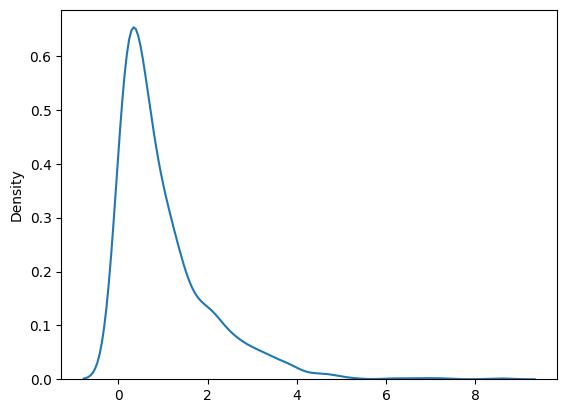

In [ ]:
from scipy.stats import boxcox

#make this example reproducible
np.random.seed(0)

#generate dataset
data = np.random.exponential(size=1000)

#plot the distribution of data values
sns.distplot(data, hist=False, kde=True)

<ipython-input-13-1b0996c33c1b>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(transformed_data, hist=False, kde=True)


<Axes: ylabel='Density'>

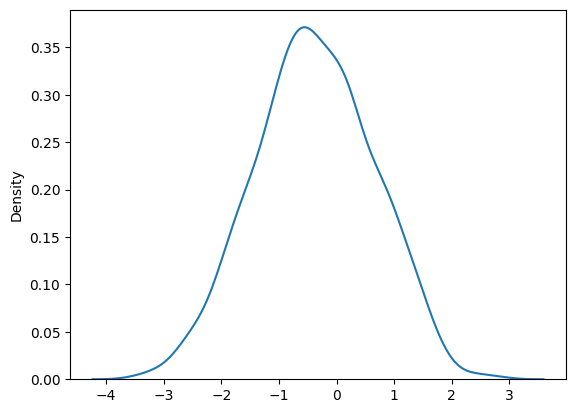

In [ ]:
#perform Box-Cox transformation on original data
transformed_data, best_lambda = boxcox(data)

#plot the distribution of the transformed data values
sns.distplot(transformed_data, hist=False, kde=True)

In [ ]:
#display optimal lambda value
print(best_lambda)

0.2420131978185579


In [ ]:
# new_data = (data^0.242 - 1) / 0.242

#view first five values of original dataset
data[0:5]

array([0.79587451, 1.25593076, 0.92322315, 0.78720115, 0.55104849])

In [ ]:
#view first five values of transformed dataset
transformed_data[0:5]

array([-0.22212062,  0.23427768, -0.07911706, -0.23247555, -0.55495228])

Imagine you're in a job search, and you're giving interviews until you land your first job.

Suppose you land a job in the first interview itself: {s}

What if you fail in your first interview, so you will give second interview and land a job in your 2nd interview: {fs}

What if you fail in your 2nd interview but land a job in 3rd interview: {ffs}...


The sample space for this situation is like a sequence of attempts will be

S = {s, fs, ffs, fffs, ...}

P(success) = p

P(failure) = 1 - p

In [ ]:
# P(X = 1) = p
# P(X = 2) = (1-p) * p
# P(X = 3) = (1-p) * (1-p) * p
#...

# P(X = k) = (1 - p)^(k-1) * p

This probability distribution is known as the Geometric Distribution. It tells us the probability of how many attempts it takes to achieve the first success.



*   The geometric distribution is a discrete probability distribution that calculates the probability of the first success occurring during a bernoulli trial.
*   This distribution is an example of a Probability Mass Function (PMF) because it calculates likelihood for discrete random variable.



In [ ]:
# p = probability of success
p = 0.1

In [ ]:
# P(X = 2) = ?
(0.9 ** 1) * 0.1

0.09000000000000001

In [ ]:
# P(X = 4) = ?
(0.9 ** 3) * 0.1

0.0729

In [ ]:
# P(X = 6) = ?
(0.9 ** 5) * 0.1

0.05904900000000001

In [ ]:
# P(X = 8) = ?
(0.9 ** 7) * 0.1

0.04782969000000001

In [ ]:
# P(X = 10) = ?
(0.9 ** 9) * 0.1

0.03874204890000001

<Axes: >

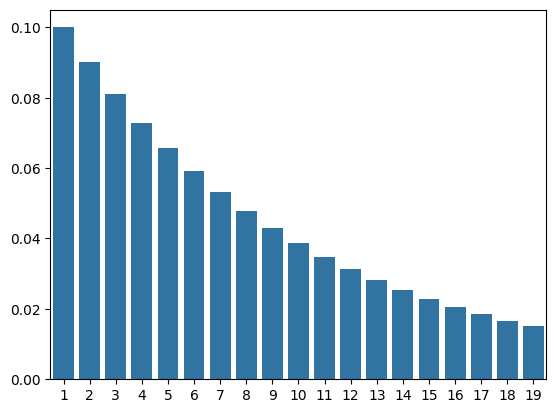

In [ ]:
# the number of trials
x_vals = np.arange(1, 20)

# The k = the number of trials, and the p = the probability of success,
# using geom.pmf() function we can calculate probability

probs_geom = geom.pmf(x_vals, p=p)
sns.barplot(x=x_vals, y=probs_geom)

You are flipping a fair coin repeatedly until you get heads for the first time.
You're interested in finding out,
on average, how many times you need to flip the coin before you get that first heads.

In [ ]:
# Geometric Distribution Mean (Expected Value) -
# The average number of attempts needed to achieve success in a series of trials.

In [ ]:
p = 0.5
e = 1/p
e

2.0

Suppose you are playing a game where success rate of winning a prize is 0.7.  
(a) What is the probability of winning a prize on 4th attempt?  
(b) What is the probability that you don't win in 2 attempts?  
(c) What is the expected number of trials to get the first success?


In [ ]:
# (a) What is the probability of winning a prize on 4th attempt?

(0.3) ** 3 * 0.7

0.018899999999999997

In [ ]:
prob = geom.pmf(k=4, p=0.7)
prob

0.018900000000000007

In [ ]:
# (b) What is the probability that you don't win in 2 attempts?
# Use the cumulative distribution function (CDF) to find the probability of not winning in 2 attempts
prob = geom.cdf(k=2, p=0.7)

not_winning_prob = 1 - prob
not_winning_prob

0.09000000000000008

In [ ]:
# (c) What is the expected number of trials to get the first success?
expected = 1/0.7
expected

1.4285714285714286

You are flipping a biased coin with a 30% chance of getting heads until you succeed.

What is the probability of getting heads on the 2nd flip?

In [ ]:
prob = geom.pmf(k=2,p =0.3)
print(prob)

0.21


In [ ]:
0.7 * 0.3

0.21

In a factory that produces light bulbs, there's a 5% chance that any given bulb is defective.

What is the probability of needing 1 or 2 bulbs to find the first defective bulb?

In [ ]:
# p = 0.05

(0.05) + (0.95 * 0.05)

0.0975

In [ ]:
geom.pmf(k=1, p=0.05) + geom.pmf(k=2, p=0.05)

0.0975

In [ ]:
geom.cdf(k=2, p=0.05)

0.0975